# Analysing the SEF output

This notebook produces summary figures from the final deliverable of the
pipeline - exported [Station Exchange Format](https://datarescue.climate.copernicus.eu/station-exchange-format-sef)
(SEF) `.tsv` files. Its purpose is to show the shared data is **useful** and to
surface **hidden bugs** before shipping.

Every figure is computed **only from the SEF files** (nothing from working
databases). Reading the raw `.tsv` tree for each figure would be slow, so SEF
files are first parsed **once** into a compact Parquet analysis dataset
(`observations` + precomputed `daily_national` aggregates) that this notebook
then queries cheaply with DuckDB. Build that dataset in parallel with the local
pipeline `scripts/local/submit_local.sh sef_analysis` (one array task per SEF
year).

> **Coverage caveat.** The station network grows enormously over the record
> (from a handful of gauges in the 18th century to thousands by the 1930s). The
> national series below are simple **means over reporting stations** each
> day/year, so absolute levels and trends are influenced by which stations
> exist - treat between-era comparisons with care. Where a metric is sensitive
> to coverage (for example extreme counts) it is shown as a **rate per reporting
> station**.

## How the analysis dataset is built

| Stage | Script | Local runner | Purpose |
|-------|--------|--------------|---------|
| convert | `scripts/build_sef_analysis_parquet.py` | `scripts/local/run_array_local.sh` | parse each SEF year into `observations/` + `daily_national/` Parquet |

There is **no merge stage**: every date belongs to exactly one year, so each
task writes disjoint `year=<Y>.parquet` files. Configuration lives in
`scripts/slurm/config.sh` under `SEFSTATS_*`; the prerequisite is the SEF export
itself (`scripts/local/submit_local.sh sef_export`). Everything lands under
`$PDIR/sef_analysis/`.

## Setup

In [2]:
import os
import sys
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Show every row of the annual summary tables (they have ~100 years).
pd.set_option("display.max_rows", None)

# Make the repository importable (the notebook runs from notebooks/).
repo_root = Path.cwd()
while not (repo_root / "src").is_dir() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from src.rainfall_rescue_sqlite.sef_analysis import (
    WET_THRESHOLD_MM,
    EXTREME_THRESHOLDS_MM,
    build_year_parquet,
    default_analysis_root,
    default_sef_root,
    discover_years,
)

os.environ.setdefault("PDIR", "/data/scratch/philip.brohan/ADRQ")
sef_root = default_sef_root()
analysis_root = default_analysis_root()
print(f"SEF export root: {sef_root}")
print(f"Analysis root:   {analysis_root}")
print(f"Extreme thresholds (mm): {EXTREME_THRESHOLDS_MM};  wet-day threshold: {WET_THRESHOLD_MM} mm")

SEF export root: /Volumes/Scratch/ADRQ/sef_export
Analysis root:   /Volumes/Scratch/ADRQ/sef_analysis
Extreme thresholds (mm): (10.0, 25.0, 50.0);  wet-day threshold: 1.0 mm


### Locate (or build a demo of) the analysis dataset

If the operational Parquet dataset does not exist yet, a small demo is built
locally into `/var/tmp` from a few SEF years so the notebook is self-contained.
For the full record, run `scripts/local/submit_local.sh sef_analysis` first and
re-run this cell.

The analysis is limited to a year range (`YEAR_MIN`-`YEAR_MAX`, default
**1860-1960**). The dataset targets that span; a few stray stations outside it
have poor QC whose errors dominate variability, so they are excluded by default.
Change the range and re-run from this cell down to widen the window.

In [3]:
DEMO_YEARS = [1903, 1921, 1931]  # a wet year, a drought year, and the busiest year

# Restrict every figure below to this inclusive year range. The dataset targets
# 1860-1960; a handful of stray stations outside it have poor QC and their errors
# dominate the variability, so they are excluded by default. Widen if you want to
# inspect them, then re-run from this cell down.
YEAR_MIN, YEAR_MAX = 1860, 1960

# Re-check the operational root freshly each run (don't rely on `analysis_root`,
# which this cell reassigns to the demo path when no operational data exists).
operational_root = default_analysis_root()
obs_dir = operational_root / "observations"
have_operational = obs_dir.is_dir() and any(obs_dir.glob("*.parquet"))

if have_operational:
    analysis_root = operational_root
    print(f"Using operational SEF analysis parquet at {analysis_root}")
else:
    print("No operational SEF analysis parquet found; building a local demo ...")
    analysis_root = Path("/var/tmp/sef_analysis_demo")
    available = set(discover_years(sef_root))
    for year in DEMO_YEARS:
        if year not in available:
            print(f"  (SEF year {year} not present in the export; skipping)")
            continue
        out = analysis_root / "observations" / f"year={year}.parquet"
        if out.exists():
            print(f"  {year}: already built")
            continue
        summary = build_year_parquet(sef_root, year, analysis_root)
        print(f"  {year}: {summary['n_observations']} obs, {summary['n_passed']} passed")


def _parquet_sources(table: str) -> str:
    # DuckDB list literal of the year=<Y>.parquet files within [YEAR_MIN, YEAR_MAX].
    # Limiting the files read at the source restricts every query and plot below.
    directory = Path(analysis_root) / table
    files = [
        str(directory / f"year={year}.parquet")
        for year in range(YEAR_MIN, YEAR_MAX + 1)
        if (directory / f"year={year}.parquet").exists()
    ]
    if not files:
        raise FileNotFoundError(
            f"No {table} parquet for years {YEAR_MIN}-{YEAR_MAX} under {directory}"
        )
    return "[" + ", ".join(f"'{f}'" for f in files) + "]"


daily_src = _parquet_sources("daily_national")
obs_src = _parquet_sources("observations")
con = duckdb.connect()


def q(sql: str) -> pd.DataFrame:
    # Run a DuckDB query; {daily} and {obs} expand to the in-range parquet file lists.
    return con.execute(sql.format(daily=daily_src, obs=obs_src)).df()


years_present = q("SELECT DISTINCT year FROM read_parquet({daily}) ORDER BY year")["year"].tolist()
print(f"Analysis root in use: {analysis_root}")
print(f"Year range examined:  {YEAR_MIN}-{YEAR_MAX}")
print(f"Years with data:      {len(years_present)} ({min(years_present)}-{max(years_present)})")


Using operational SEF analysis parquet at /Volumes/Scratch/ADRQ/sef_analysis
Analysis root in use: /Volumes/Scratch/ADRQ/sef_analysis
Year range examined:  1860-1960
Years with data:      101 (1860-1960)


## 1. Observation coverage

How many stations report, how many observations they contribute, and what
fraction meet the QC criteria to be trusted (`qc1 == pass` or `qc2` was not a
definitive fail). A healthy export should pass the great majority of
observations; a sudden dip would point to a QC or export bug.

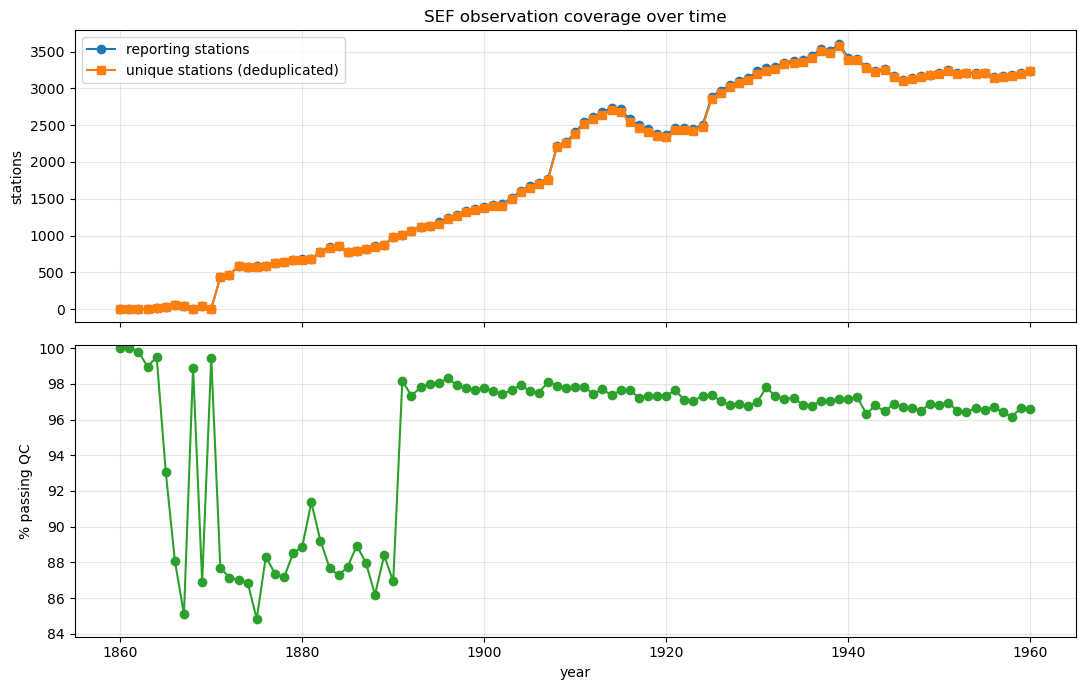

,year,n_obs,n_stations,n_unique_stations,pct_passed
0,1860,366,1,1,100.00
1,1861,2190,6,6,100.00
2,1862,2190,6,6,99.82
3,1863,1825,5,5,98.96
4,1864,4026,11,11,99.53
5,1865,10585,29,29,93.06
6,1866,18615,51,51,88.10
7,1867,17885,49,49,85.09
8,1868,2196,6,6,98.91
9,1869,17520,48,48,86.91


In [6]:
coverage = q('''
    SELECT year,
        count(*) AS n_obs,
        count(DISTINCT station_id) AS n_stations,
        count(DISTINCT (latitude || ',' || longitude)) AS n_unique_stations,
        100.0 * sum(passed::int) / count(*) AS pct_passed
    FROM read_parquet({obs})
    GROUP BY year ORDER BY year
''')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax1.plot(coverage["year"], coverage["n_stations"], "-o", color="#1f77b4",
         label="reporting stations")
ax1.plot(coverage["year"], coverage["n_unique_stations"], "-s", color="#ff7f0e",
         label="unique stations (deduplicated)")
ax1.set_ylabel("stations")
ax1.set_title("SEF observation coverage over time")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(coverage["year"], coverage["pct_passed"], "-o", color="#2ca02c")
ax2.set_ylabel("% passing QC")
ax2.set_xlabel("year")
ax2.set_ylim(min(90, coverage["pct_passed"].min() - 1), 100.2)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

coverage.assign(pct_passed=coverage["pct_passed"].round(2))


## 1b. QC pass fraction in detail

Section 1 tracked the single "trusted" pass rate. Here we break it into the two
independent checks and hunt for outliers.

* **QC1** (the primary check) runs on **every** observation; its verdicts are
  `pass` / `review` / `fail`.
* **QC2** (the secondary ML check) runs **only on the observations QC1 failed**,
  deciding whether to rescue them (`pass` / `indeterminate`) or confirm the
  rejection (`fail`). Its pass rate is measured over a much smaller,
  year-varying denominator (the QC1 failures), so it sits on a very different
  scale from QC1 and gets its **own panel** below rather than being squashed
  onto the same axis.

A healthy export has a high, stable QC1 pass rate. Sudden dips, or individual
months / stations with very low rates, usually point to a transcription batch or
a QC bug rather than genuine weather.


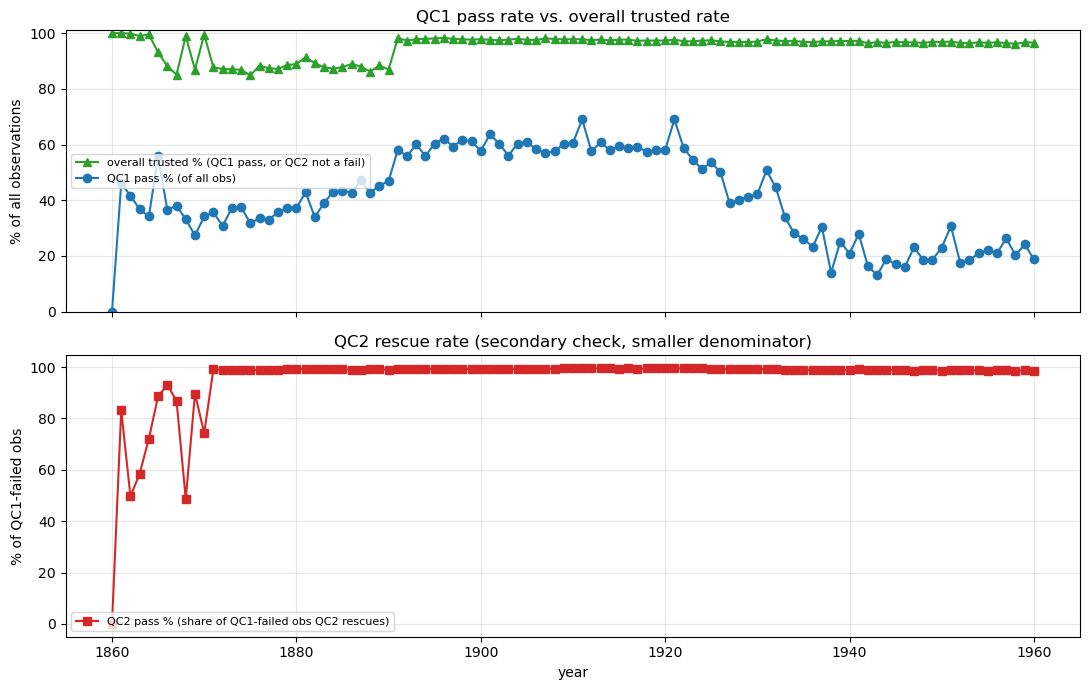

,year,n_obs,qc1_pass_pct,qc1_review_pct,qc1_fail_pct,n_qc2,qc2_pass_pct,trusted_pct
0,1860,366,0.00,0.0,100.00,366,0.00,100.00
1,1861,2190,46.03,0.0,53.97,2190,83.20,100.00
2,1862,2190,41.64,0.0,58.36,2190,49.68,99.82
3,1863,1825,36.77,0.0,63.23,1825,58.47,98.96
4,1864,4026,34.15,0.0,65.85,4026,72.13,99.53
5,1865,10585,55.70,0.0,37.40,9855,88.64,93.06
6,1866,18615,36.61,0.0,51.63,16425,92.99,88.10
7,1867,17885,38.04,0.0,47.68,15330,86.89,85.09
8,1868,2196,33.15,0.0,66.85,2196,48.59,98.91
9,1869,17520,27.35,0.0,60.15,15330,89.66,86.91


In [7]:
qc_year = q('''
    SELECT year,
        count(*) AS n_obs,
        100.0 * avg((lower(qc1) = 'pass')::int)   AS qc1_pass_pct,
        100.0 * avg((lower(qc1) = 'review')::int) AS qc1_review_pct,
        100.0 * avg((lower(qc1) = 'fail')::int)   AS qc1_fail_pct,
        count(*) FILTER (WHERE lower(qc2) <> 'na') AS n_qc2,
        100.0 * avg((lower(qc2) = 'pass')::int)
            FILTER (WHERE lower(qc2) <> 'na')       AS qc2_pass_pct,
        100.0 * avg(passed::int)                    AS trusted_pct
    FROM read_parquet({obs})
    GROUP BY year ORDER BY year
''')

# QC1 (of all obs) and the overall trusted rate share the "% of all observations"
# scale, so they go together on top. QC2 is measured over a different, much smaller
# pool (the QC1 failures) and runs at a very different level, so it gets its own
# auto-scaled panel below instead of being flattened onto the same axis.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(qc_year["year"], qc_year["trusted_pct"], "-^", color="#2ca02c",
         label="overall trusted % (QC1 pass, or QC2 not a fail)")
ax1.plot(qc_year["year"], qc_year["qc1_pass_pct"], "-o", color="#1f77b4",
         label="QC1 pass % (of all obs)")
ax1.set_ylabel("% of all observations")
ax1.set_ylim(0, 101)
ax1.set_title("QC1 pass rate vs. overall trusted rate")
ax1.legend(fontsize=8, loc="center left")
ax1.grid(alpha=0.3)

ax2.plot(qc_year["year"], qc_year["qc2_pass_pct"], "-s", color="#d62728",
         label="QC2 pass % (share of QC1-failed obs QC2 rescues)")
ax2.set_ylabel("% of QC1-failed obs")
ax2.set_xlabel("year")
ax2.set_title("QC2 rescue rate (secondary check, smaller denominator)")
ax2.legend(fontsize=8, loc="lower left")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

qc_year.assign(
    qc1_pass_pct=qc_year["qc1_pass_pct"].round(2),
    qc1_review_pct=qc_year["qc1_review_pct"].round(2),
    qc1_fail_pct=qc_year["qc1_fail_pct"].round(2),

    qc2_pass_pct=qc_year["qc2_pass_pct"].round(2),

    trusted_pct=qc_year["trusted_pct"].round(2),)

### Months with exceptional QC pass / fail rates

QC1 is assigned per **station-month** -- one verdict covers a whole month of a
station's record -- so every day within a station's month shares it and a
day-by-day view carries no extra information. The natural unit is therefore the
**calendar month**: for each month we collapse to one row per station and then
take the fraction of those stations whose month passed QC1. Months where an
unusually large fraction of stations **fail** are prime suspects for a systematic
problem -- a mis-scanned page batch or a bad ledger -- rather than genuine
weather. Sparse months are excluded so the rates are not small-sample noise.


In [ ]:
MIN_STATIONS_PER_MONTH = 30  # ignore sparse months whose rates are just small-sample noise

# QC1 is a per-station-month verdict, so first collapse each station's month to a
# single row (max == any value, since all its days agree), then aggregate over the
# reporting stations for each calendar month.
monthly_qc = con.execute(f'''
    WITH station_month AS (
        SELECT station_id, year, month,
            make_date(year, month, 1) AS month_start,
            max((lower(qc1) = 'pass')::int) AS qc1_pass,
            max(passed::int) AS trusted
        FROM read_parquet({obs_src})
        GROUP BY station_id, year, month
    )
    SELECT month_start, year, month,
        count(*) AS n_stations,
        100.0 * avg(qc1_pass) AS qc1_pass_pct,
        100.0 * avg(trusted) AS trusted_pct
    FROM station_month
    GROUP BY month_start, year, month
    HAVING count(*) >= {MIN_STATIONS_PER_MONTH}
''').df()

worst_months = monthly_qc.sort_values("qc1_pass_pct").head(12).reset_index(drop=True)
best_months = monthly_qc.sort_values("qc1_pass_pct", ascending=False).head(12).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(monthly_qc["qc1_pass_pct"], bins=40, color="#1f77b4", alpha=0.8)
ax.axvline(monthly_qc["qc1_pass_pct"].median(), ls="--", color="grey",
           label=f"median {monthly_qc['qc1_pass_pct'].median():.1f}%")
ax.set_xlabel("monthly QC1 pass rate (%)")
ax.set_ylabel("number of months")
ax.set_title(f"Distribution of monthly QC1 pass rate (months with >= {MIN_STATIONS_PER_MONTH} stations)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{len(monthly_qc)} months with >= {MIN_STATIONS_PER_MONTH} reporting stations")
print("\nWorst 12 months by QC1 pass rate (candidate systematic problems):")
display(worst_months.round(2))
print("\nMonths with the highest QC1 pass rate:")
display(best_months.round(2))


### Stations with exceptional QC pass / fail rates

The same idea per station, aggregated over all its days in range. A station that
fails QC1 far more often than its peers is worth inspecting -- it may have a
transcription issue, sit at an outlier location, or expose a QC edge case.
Stations with too few observations are excluded so the rates are meaningful.


In [ ]:
from IPython.display import display

MIN_OBS_PER_STATION = 120  # ~a third of a year; drop stations with only a few days

station_qc = con.execute(f'''
    SELECT station_id,
        any_value(location_name) AS location_name,
        round(any_value(latitude), 3) AS lat,
        round(any_value(longitude), 3) AS lon,
        count(*) AS n_obs,
        100.0 * avg((lower(qc1) = 'pass')::int) AS qc1_pass_pct,
        100.0 * avg(passed::int) AS trusted_pct
    FROM read_parquet({obs_src})
    GROUP BY station_id
    HAVING count(*) >= {MIN_OBS_PER_STATION}
''').df()

worst_stations = station_qc.sort_values("qc1_pass_pct").head(15).reset_index(drop=True)
best_stations = station_qc.sort_values("qc1_pass_pct", ascending=False).head(15).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(station_qc["qc1_pass_pct"], bins=40, color="#2ca02c", alpha=0.8)
ax.axvline(station_qc["qc1_pass_pct"].median(), ls="--", color="grey",
           label=f"median {station_qc['qc1_pass_pct'].median():.1f}%")
ax.set_xlabel("per-station QC1 pass rate (%)")
ax.set_ylabel("number of stations")
ax.set_title(f"Distribution of per-station QC1 pass rate (>= {MIN_OBS_PER_STATION} obs)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{len(station_qc)} stations with >= {MIN_OBS_PER_STATION} observations in range")
print("\nWorst 15 stations by QC1 pass rate (look here for transcription / QC problems):")
display(worst_stations.round(2))
print("\nBest 15 stations by QC1 pass rate:")
display(best_stations.round(2))


## 2. Trends in rainfall

National-mean daily rainfall (mean over reporting stations) aggregated to an
annual total. *Absolute levels are coverage-influenced (see the caveat above);
this is most useful as a check that year-to-year variability looks physical and
that no year is wildly out of range.*

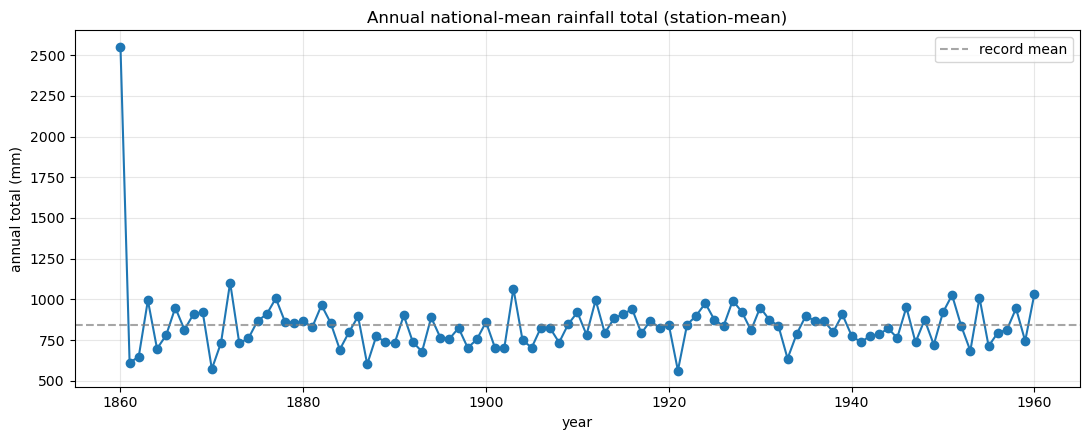

,year,mean_daily_mm,annual_total_mm,station_days
0,1860,6.975,2552.9,366.0
1,1861,1.671,609.8,2190.0
2,1862,1.778,649.0,2186.0
3,1863,2.724,994.2,1806.0
4,1864,1.905,697.2,4007.0
5,1865,2.137,779.9,9850.0
6,1866,2.601,949.2,16399.0
7,1867,2.229,813.7,15219.0
8,1868,2.487,910.1,2172.0
9,1869,2.525,921.5,15227.0


In [8]:
annual = q('''
    SELECT year,
        avg(mean_mm) AS mean_daily_mm,
        sum(mean_mm) AS annual_total_mm,
        sum(n_stations_reporting) AS station_days
    FROM read_parquet({daily})
    GROUP BY year ORDER BY year
''')

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(annual["year"], annual["annual_total_mm"], "-o", color="#1f77b4")
if len(annual) > 1:
    ax.axhline(annual["annual_total_mm"].mean(), ls="--", color="grey", alpha=0.7,
               label="record mean")
    ax.legend()
ax.set_title("Annual national-mean rainfall total (station-mean)")
ax.set_ylabel("annual total (mm)")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

annual.assign(annual_total_mm=annual["annual_total_mm"].round(1),
              mean_daily_mm=annual["mean_daily_mm"].round(3))

## 3. Trends in rainfall intensity

Two coverage-robust intensity measures, computed per year over the trusted
observations:

* **SDII** (Simple Daily Intensity Index) -- the mean rainfall on *wet* days
  (>= 1 mm). Independent of how many dry days or stations there are.
* **Wet-day fraction** -- the share of station-days that are wet.

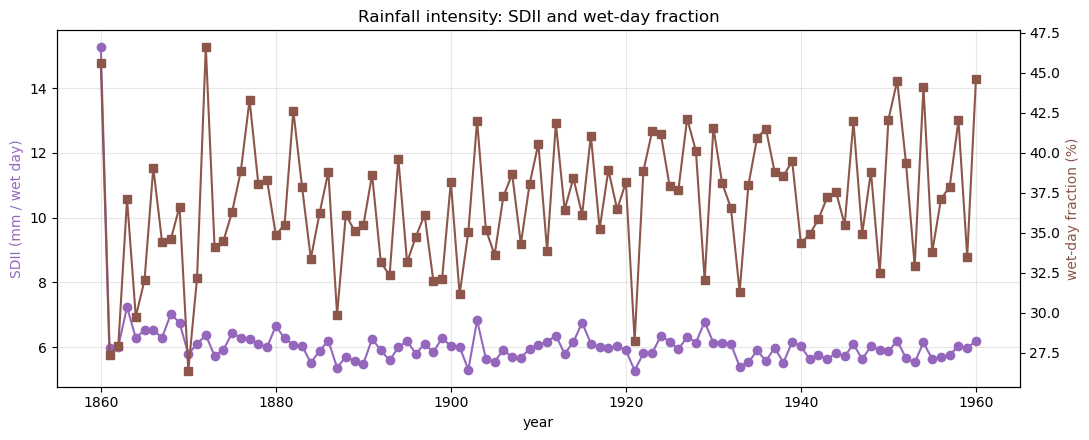

,year,sdii_mm,wet_fraction
0,1860,15.28,45.6
1,1861,5.98,27.4
2,1862,6.02,27.9
3,1863,7.24,37.1
4,1864,6.29,29.7
5,1865,6.53,32.0
6,1866,6.53,39.1
7,1867,6.30,34.4
8,1868,7.03,34.6
9,1869,6.76,36.6


In [9]:
intensity = q('''
    SELECT year,
        avg(value_mm) FILTER (WHERE passed AND value_mm >= {wet}) AS sdii_mm,
        avg((passed AND value_mm >= {wet})::int)
            FILTER (WHERE passed AND value_mm IS NOT NULL) AS wet_fraction
    FROM read_parquet({{obs}})
    GROUP BY year ORDER BY year
'''.format(wet=WET_THRESHOLD_MM))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(intensity["year"], intensity["sdii_mm"], "-o", color="#9467bd", label="SDII (mean wet-day mm)")
ax.set_ylabel("SDII (mm / wet day)", color="#9467bd")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
axb = ax.twinx()
axb.plot(intensity["year"], 100 * intensity["wet_fraction"], "-s", color="#8c564b",
         label="wet-day %")
axb.set_ylabel("wet-day fraction (%)", color="#8c564b")
ax.set_title("Rainfall intensity: SDII and wet-day fraction")
plt.tight_layout()
plt.show()

intensity.assign(sdii_mm=intensity["sdii_mm"].round(2),
                 wet_fraction=(100 * intensity["wet_fraction"]).round(1))

## 4. Wettest days

The wettest days by **national mean** rainfall (a widespread soaking), and the
most extreme individual **station-days** (a single very large gauge reading --
also a useful place to look for transcription/units bugs).

The national-mean ranking is restricted to **1880 onwards**: before then only a
handful of gauges report, so the mean over them is dominated by sampling noise
and the top days would all be spurious early-record artifacts. The individual
station-day extremes are single readings and so are not coverage-sensitive.

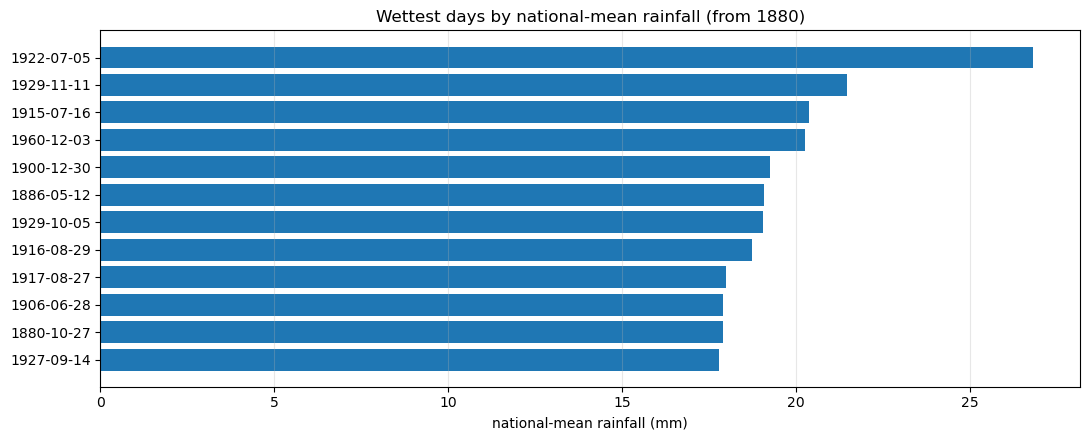

Most extreme individual station-days:


,obs_date,station_id,location_name,value_mm,lat,lon
0,1954-08-28,DRain_1951-1962_RainNos_2954-2988_B045-13,LOCH TURRET (LOWER SHAGGIE),551.2,56.432,-3.826
1,1928-01-12,DRain_1921-1930_RainNos_Lancashire_Mo-Ro_B001-8,MORECAMBE,525.8,54.073,-2.871
2,1951-02-28,DRain_1951-1962_RainNos_4337-4375_B037-1,LLANBEDR-Y-CENNIN LLYNDULYN,520.7,53.179,-3.937
3,1954-10-19,DRain_1951-1962_RainNos_2954-2988_B045-13,LOCH TURRET (LOWER SHAGGIE),442.0,56.432,-3.826
4,1954-01-25,DRain_1951-1962_RainNos_2954-2988_B045-13,LOCH TURRET (LOWER SHAGGIE),388.6,56.432,-3.826
5,1926-11-08,DRain_1921-1930_RainNos_Essex_A-H_B019-9,CHELMSFORD-HORTICULTURAL,373.4,51.734,0.430
6,1954-12-22,DRain_1951-1962_RainNos_2954-2988_B045-13,LOCH TURRET (LOWER SHAGGIE),312.4,56.432,-3.826
7,1954-09-06,DRain_1951-1962_RainNos_2954-2988_B045-13,LOCH TURRET (LOWER SHAGGIE),287.0,56.432,-3.826
8,1946-11-27,DRain_1941-1950_RainNos_4001-4038-474,FAIRWOOD-COMMON-AIRFIELD,284.5,51.602,-4.069
9,1946-12-22,DRain_1941-1950_RainNos_4001-4038-474,FAIRWOOD-COMMON-AIRFIELD,281.9,51.602,-4.069


In [10]:
wettest_national = q('''
    SELECT obs_date, n_stations_reporting,
        round(mean_mm, 2) AS mean_mm, round(max_mm, 1) AS max_mm, argmax_location
    FROM read_parquet({daily})
    WHERE year >= 1880
    ORDER BY mean_mm DESC LIMIT 12
''')

fig, ax = plt.subplots(figsize=(11, 4.5))
labels = wettest_national["obs_date"].astype(str)
ax.barh(labels[::-1], wettest_national["mean_mm"][::-1], color="#1f77b4")
ax.set_xlabel("national-mean rainfall (mm)")
ax.set_title("Wettest days by national-mean rainfall (from 1880)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("Most extreme individual station-days:")
q('''
    SELECT obs_date, station_id, location_name, round(value_mm, 1) AS value_mm,
        round(latitude, 3) AS lat, round(longitude, 3) AS lon
    FROM read_parquet({obs})
    WHERE passed AND value_mm IS NOT NULL
    ORDER BY value_mm DESC LIMIT 12
''')

## 5. Extreme rainfall frequency

How often heavy-rain days occur, shown as a **rate per 1000 reporting
station-days** so it is not simply tracking the growing network. Thresholds are
the `EXTREME_THRESHOLDS_MM` used when the dataset was built.

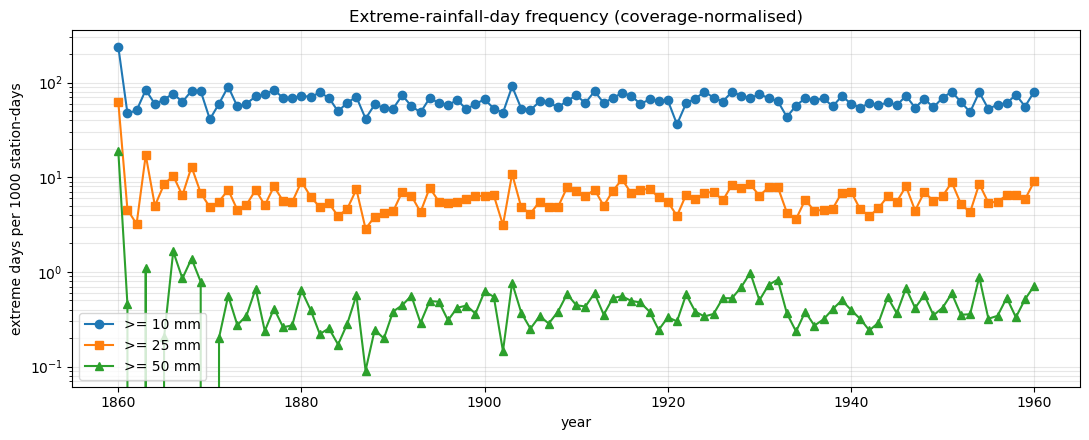

,year,ge10_rate,ge25_rate,ge50_rate
0,1860,240.437,62.842,19.126
1,1861,47.489,4.566,0.457
2,1862,50.778,3.202,0.000
3,1863,83.610,17.165,1.107
4,1864,59.396,4.991,0.000
5,1865,66.294,8.426,0.203
6,1866,76.712,10.366,1.646
7,1867,62.488,6.439,0.854
8,1868,81.952,12.891,1.381
9,1869,81.369,6.830,0.788


In [11]:
ge10, ge25, ge50 = EXTREME_THRESHOLDS_MM
extremes = q('''
    SELECT year,
        1000.0 * sum(n_ge10) / sum(n_stations_reporting) AS ge10_rate,
        1000.0 * sum(n_ge25) / sum(n_stations_reporting) AS ge25_rate,
        1000.0 * sum(n_ge50) / sum(n_stations_reporting) AS ge50_rate
    FROM read_parquet({daily})
    GROUP BY year ORDER BY year
''')

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(extremes["year"], extremes["ge10_rate"], "-o", label=f">= {ge10:.0f} mm")
ax.plot(extremes["year"], extremes["ge25_rate"], "-s", label=f">= {ge25:.0f} mm")
ax.plot(extremes["year"], extremes["ge50_rate"], "-^", label=f">= {ge50:.0f} mm")
ax.set_yscale("log")
ax.set_ylabel("extreme days per 1000 station-days")
ax.set_xlabel("year")
ax.set_title("Extreme-rainfall-day frequency (coverage-normalised)")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

extremes.round(3)

## 6. Known historical events

A quick cross-check against documented UK rainfall history. If the SEF data is
faithful, well-known **floods** should coincide with wet extremes and
**droughts** with dry years. The events below are annotated on the annual-mean
series; where the event's year is in the loaded data a SEF-derived daily map is
drawn.

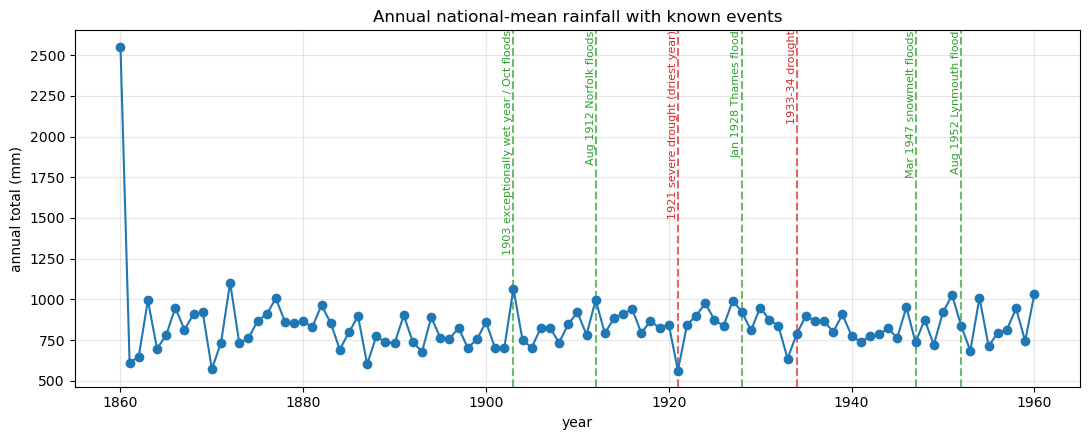

Events within the loaded record:
  1903-10-27  flood     1903 exceptionally wet year / Oct floods
  1912-08-26  flood     Aug 1912 Norfolk floods
  1921-07-01  drought   1921 severe drought (driest year)
  1928-01-07  flood     Jan 1928 Thames flood
  1934-01-01  drought   1933-34 drought
  1947-03-16  flood     Mar 1947 snowmelt floods
  1952-08-15  flood     Aug 1952 Lynmouth flood


In [12]:
# Curated major UK rainfall events (date used for the event map; year for annotation).
EVENTS = [
    {"date": "1903-10-27", "year": 1903, "kind": "flood",
     "label": "1903 exceptionally wet year / Oct floods"},
    {"date": "1912-08-26", "year": 1912, "kind": "flood",
     "label": "Aug 1912 Norfolk floods"},
    {"date": "1921-07-01", "year": 1921, "kind": "drought",
     "label": "1921 severe drought (driest year)"},
    {"date": "1928-01-07", "year": 1928, "kind": "flood",
     "label": "Jan 1928 Thames flood"},
    {"date": "1934-01-01", "year": 1934, "kind": "drought",
     "label": "1933-34 drought"},
    {"date": "1947-03-16", "year": 1947, "kind": "flood",
     "label": "Mar 1947 snowmelt floods"},
    {"date": "1952-08-15", "year": 1952, "kind": "flood",
     "label": "Aug 1952 Lynmouth flood"},
]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(annual["year"], annual["annual_total_mm"], "-o", color="#1f77b4", zorder=5)
ax.set_title("Annual national-mean rainfall with known events")
ax.set_ylabel("annual total (mm)")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
ymin, ymax = ax.get_ylim()
for ev in EVENTS:
    if not (annual["year"].min() <= ev["year"] <= annual["year"].max()):
        continue
    colour = "#2ca02c" if ev["kind"] == "flood" else "#d62728"
    ax.axvline(ev["year"], color=colour, ls="--", alpha=0.7)
    ax.text(ev["year"], ymax, ev["label"], rotation=90, va="top", ha="right",
            fontsize=8, color=colour)
plt.tight_layout()
plt.show()

in_range = [e for e in EVENTS if annual["year"].min() <= e["year"] <= annual["year"].max()]
print("Events within the loaded record:")
for e in in_range:
    print(f"  {e['date']}  {e['kind']:8s}  {e['label']}")

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_event_map(event_date: str, vmax: float = 50.0):
    # Map SEF daily rainfall across reporting stations for one date.
    df = q(f'''
        SELECT longitude, latitude, value_mm
        FROM read_parquet({{obs}})
        WHERE obs_date = DATE '{event_date}' AND passed AND value_mm IS NOT NULL
        ORDER BY value_mm
    ''')
    if df.empty:
        print(f"No SEF observations available for {event_date} "
              f"(is its year in the loaded dataset?)")
        return

    fig = plt.figure(figsize=(7, 9))
    ax = fig.add_axes([0.02, 0.05, 0.84, 0.9], projection=ccrs.PlateCarree())
    ax.set_extent([-11, 4, 49, 61], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="#f2efe9")
    ax.coastlines(resolution="50m", linewidth=0.8, color="black")
    sc = ax.scatter(df["longitude"], df["latitude"], c=np.sqrt(df["value_mm"]),
                    cmap="YlGnBu", vmin=0, vmax=np.sqrt(vmax), s=14,
                    edgecolor="black", linewidth=0.2,
                    transform=ccrs.PlateCarree(), zorder=20)
    cax = fig.add_axes([0.88, 0.1, 0.03, 0.8])
    ticks = np.array([0, 1, 5, 10, 25, 50])
    cbar = fig.colorbar(sc, cax=cax, extend="max", ticks=np.sqrt(ticks))
    cbar.ax.set_yticklabels([str(t) for t in ticks])
    cbar.set_label("daily rainfall (mm)")
    ax.set_title(f"SEF daily rainfall  {event_date}\n{len(df)} stations reporting")
    plt.show()


# Map the first in-range event (with the demo data this is the 1903 flood).
if in_range:
    plot_event_map(in_range[0]["date"])
else:
    print("No curated events fall within the loaded years; run the full build to see event maps.")

## 7. Long dry spells

Per station, find every run of **consecutive dry days** and list the longest.
A *dry day* is a trusted (`passed`) observation with rainfall below the wet-day
threshold; a *dry spell* is a maximal run of consecutive calendar dates that are
all dry. A wet day **or** a gap in the record (a missing day) ends the spell, so
each spell is a genuinely continuous stretch of *observed* dry days — never an
artefact of missing data.

To avoid flagging transcription blanks, any **station-year with no wet day at
all** (a physically impossible rain-free UK year, i.e. an all-zero transcription)
is discarded before spells are measured — otherwise these would top the list
with ~365-day runs.

Tune `DRY_THRESHOLD_MM` (lower it for near-literal zero) and `MIN_SPELL_DAYS`.
Results are limited to the loaded `YEAR_MIN`–`YEAR_MAX` range, so a spell
straddling that boundary may be truncated, and spells only span years where a
station keeps the same SEF `ID` across them.


In [13]:
# A "dry day" is a trusted (passed) observation with rainfall below the wet-day
# threshold. A "dry spell" is a maximal run of CONSECUTIVE calendar days at one
# station where every day is dry. A wet day OR a gap in the record (a missing
# day) ends the spell, so every spell listed is a genuinely continuous stretch
# of *observed* dry days -- never an artefact of missing data.
#
# We also DISCARD any station-year that is entirely blank -- i.e. records no wet
# day at all across the whole year. A rain-free UK year is physically
# impossible, so such years are all-zero (no-data) transcriptions rather than
# real dry spells, and would otherwise dominate the list with ~365-day runs.

DRY_THRESHOLD_MM = WET_THRESHOLD_MM  # dry = value_mm < this (1.0 mm); lower it
                                     # (e.g. 0.05) to require near-literal zero.
MIN_SPELL_DAYS = 30                  # only list spells at least this long

# Gaps-and-islands: for each station, number the dry days in date order. For a
# run of consecutive calendar dates, (obs_date - row_number) is constant, so it
# labels the island; any wet/missing day shifts it and starts a new island.
dry_spells = q(f"""
    WITH obs AS (
        SELECT station_id, obs_date, value_mm,
               CAST(year(obs_date) AS INTEGER) AS obs_year
        FROM read_parquet({{obs}})
        WHERE passed AND value_mm IS NOT NULL
    ),
    -- A station-year with no wet day at all is a blank/all-zero transcription;
    -- drop every day in such years so they can't form (spurious) dry spells.
    blank_years AS (
        SELECT station_id, obs_year
        FROM obs
        GROUP BY station_id, obs_year
        HAVING max(value_mm) < {DRY_THRESHOLD_MM}
    ),
    dry AS (
        SELECT DISTINCT o.station_id, o.obs_date
        FROM obs o
        LEFT JOIN blank_years b
          ON b.station_id = o.station_id AND b.obs_year = o.obs_year
        WHERE o.value_mm < {DRY_THRESHOLD_MM}
          AND b.station_id IS NULL
    ),
    islands AS (
        SELECT station_id, obs_date,
               obs_date - CAST(
                   row_number() OVER (PARTITION BY station_id ORDER BY obs_date)
                   AS INTEGER
               ) AS grp
        FROM dry
    ),
    spells AS (
        SELECT station_id, grp,
               min(obs_date) AS start_date,
               max(obs_date) AS end_date,
               count(*)      AS length_days
        FROM islands
        GROUP BY station_id, grp
    ),
    meta AS (
        SELECT station_id,
               any_value(location_name) AS location_name,
               any_value(latitude)      AS latitude,
               any_value(longitude)     AS longitude
        FROM read_parquet({{obs}})
        GROUP BY station_id
    )
    SELECT s.length_days, s.start_date, s.end_date, s.station_id,
           m.location_name, m.latitude, m.longitude
    FROM spells s
    JOIN meta m USING (station_id)
    WHERE s.length_days >= {MIN_SPELL_DAYS}
    ORDER BY s.length_days DESC, s.start_date
""")

# How many blank station-years were discarded (for context).
blank_year_count = q(f"""
    WITH obs AS (
        SELECT station_id, CAST(year(obs_date) AS INTEGER) AS obs_year, value_mm
        FROM read_parquet({{obs}})
        WHERE passed AND value_mm IS NOT NULL
    )
    SELECT count(*) AS n
    FROM (
        SELECT station_id, obs_year
        FROM obs
        GROUP BY station_id, obs_year
        HAVING max(value_mm) < {DRY_THRESHOLD_MM}
    )
""")["n"].iloc[0]

print(f"Dry-day definition : rainfall < {DRY_THRESHOLD_MM} mm (passed obs only)")
print(f"Minimum length     : {MIN_SPELL_DAYS} consecutive days")
print(f"Blank years dropped : {blank_year_count:,} (no wet day all year)")
print(f"Spells found        : {len(dry_spells):,}")
if not dry_spells.empty:
    top = dry_spells.iloc[0]
    print(
        f"Longest             : {top['length_days']} days at "
        f"{top['location_name'] or top['station_id']} "
        f"({top['start_date']} -> {top['end_date']})"
    )

# `dry_spells` holds the full table, ordered longest first; show the top 25.
dry_spells.head(250)

Dry-day definition : rainfall < 1.0 mm (passed obs only)
Minimum length     : 30 consecutive days
Blank years dropped : 26 (no wet day all year)
Spells found        : 29,311
Longest             : 349 days at TEIGNMOUTH-WESTBROOK-(LANDSCORE-VILLA) (1877-01-03 00:00:00 -> 1877-12-17 00:00:00)


,length_days,start_date,end_date,station_id,location_name,latitude,longitude
0,349,1877-01-03,1877-12-17,DRain_1871-1880_Devonshire_Part3-76,TEIGNMOUTH-WESTBROOK-(LANDSCORE-VILLA),50.5505,-3.5010
1,341,1917-01-01,1917-12-07,DRain_1911-1920_RainNos_Devon_A-E-450,CREDITON-OKEFIELD,50.7945,-3.6585
2,327,1862-02-08,1862-12-31,DRain_1921-1930_RainNos_Cardiganshire-7,NEWCASTLE ON TYNE,54.9790,-1.6312
3,317,1909-01-01,1909-11-13,DRain_1901-1910_RainNos_Lincolnshire_B037-2,IRBY-ON-HUMBER,53.5250,-0.1970
4,304,1931-02-01,1931-12-01,DRain_1931-1940_RainNos_2578-2612-26,SWINDERBY - LING MOOR,53.1620,-0.6910
5,290,1958-01-01,1958-10-17,DRain_1951-1962_RainNos_1837-1890_B005-0,GUNN-GROVE-COTTAGE,51.0842,-3.9524
6,288,1910-03-19,1910-12-31,DRain_1901-1910_RainNos_Somerset_J-Y_Box2_B005-0,LANGFORD-BUDVILLE-RITHERDONS,50.9995,-3.2711
7,286,1946-01-01,1946-10-13,DRain_1941-1950_RainNos_4080-4113-369,CYNGHORDY-CLYNSAER,52.0585,-3.7138
8,284,1938-01-01,1938-10-11,DRain_1931-1940_RainNos_0451-0472-354,RUDGWICK-SWAYNES,51.0859,-0.4423
9,281,1875-01-01,1875-10-08,DRain_1871-1880_Huntingdonshire-14,ST-NEOTS-WARESLEY VICARAGE,52.1746,-0.1724


### Next steps

Once these figures look right on demo years, build the **full** analysis
dataset with the local pipeline and re-run the notebook top to bottom:

```bash
scripts/local/submit_local.sh sef_analysis
```

The trends then span the whole SEF record and event annotations line up with
documented floods and droughts.

In [4]:
range_obs = q("""
SELECT COUNT(*) AS n
FROM read_parquet({obs})
""").iloc[0]["n"]

full_obs = con.execute(
    f"SELECT COUNT(*) AS n FROM read_parquet('{analysis_root}/observations/year=*.parquet')"
).fetchone()[0]

print(f"Observations in current notebook year range ({YEAR_MIN}-{YEAR_MAX}): {int(range_obs):,}")
print(f"Observations across all SEF analysis years under {analysis_root}: {int(full_obs):,}")

Observations in current notebook year range (1860-1960): 71,824,354
Observations across all SEF analysis years under /Volumes/Scratch/ADRQ/sef_analysis: 71,830,560
